# VinDatathon 2026 — Phần 3: Forecasting Pipeline

## 0. Setup

In [1]:
!pip install lightgbm prophet --quiet

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings, logging
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
DATA_DIR = Path('/content/drive/MyDrive/Datathon')
OUT_DIR  = Path('./datathon')
OUT_DIR.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load dữ liệu

In [4]:
sales = pd.read_csv(DATA_DIR/'sales.csv', parse_dates=['Date'])
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


## 2. EDA

### 2.1 Timeline Revenue & COGS

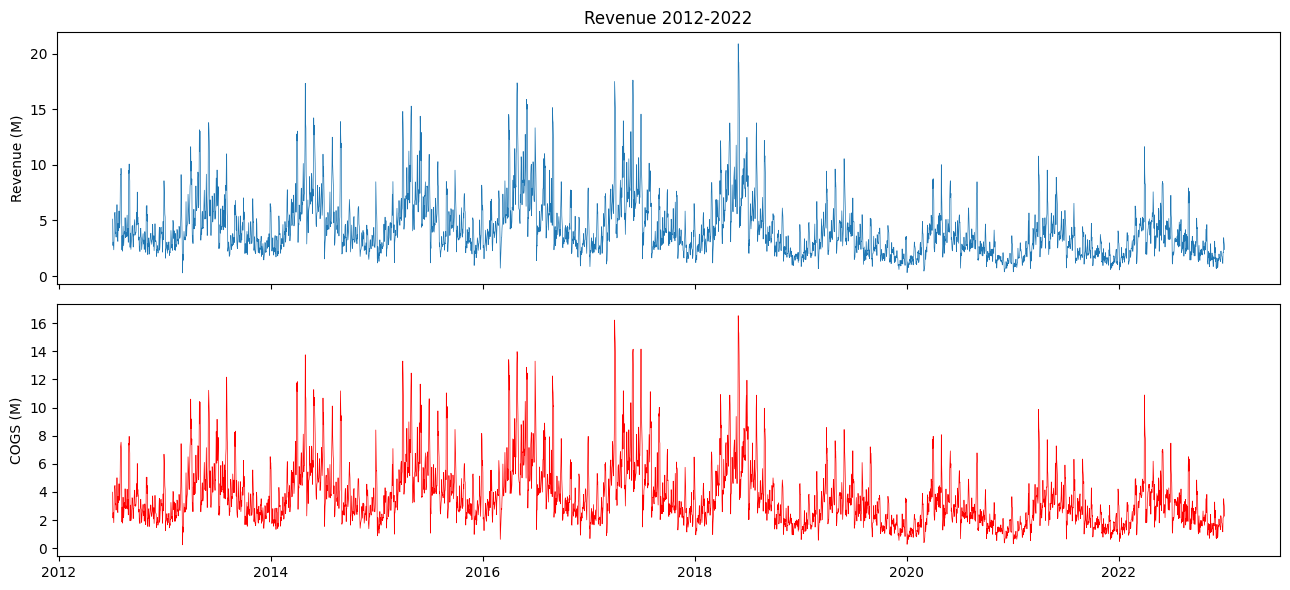

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()

### 2.2 Monthly seasonality

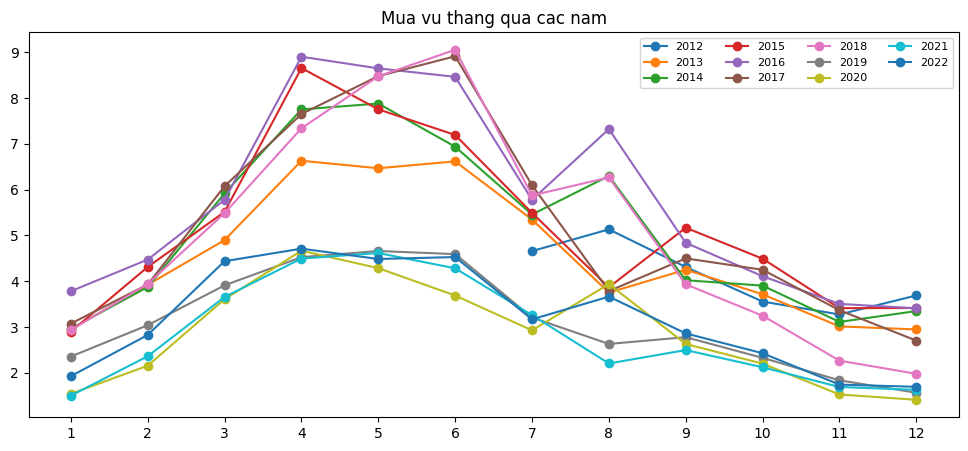

In [6]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mua vu thang qua cac nam')
plt.show()

### 2.3 Quarterly margin (Q3 zigzag chẵn/lẻ)

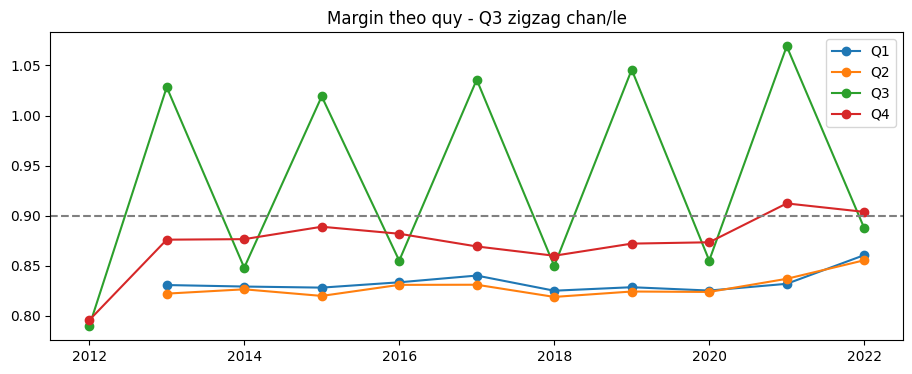

In [7]:
q_marg = sales.groupby(['Y','Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups=False).reset_index()
q_marg.columns = ['Y','Q','margin']

fig, ax = plt.subplots(figsize=(11, 4))
for q in [1,2,3,4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker='o', label=f'Q{q}')
ax.axhline(0.9, color='gray', ls='--')
ax.set_title('Margin theo quy - Q3 zigzag chan/le')
ax.legend(); plt.show()

## 3. Feature Engineering — calendar-only


In [8]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15,   'odd'),
]

In [9]:
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # Calendar
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow']>=5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge of month
    for k in [1,2,3]:
        df[f'is_last{k}']  = (df['days_to_eom']  <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # Trend + regime
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # Fourier
    TAU = 2*np.pi
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(TAU*k*df['doy']/365.25)
        df[f'cos_y{k}'] = np.cos(TAU*k*df['doy']/365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU*k*df['dow']/7.0)
        df[f'cos_w{k}'] = np.cos(TAU*k*df['dow']/7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU*k*(df['day']-1)/df['dim'])

    # Promo windows
    yrs = sorted(set(df['year'].tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount= np.zeros(len(df))
        for y in range(min(yrs)-1, max(yrs)+2):
            if recur=='odd' and y%2==0: continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d>=start) & (d<=end)
            in_prom[mask] = 1
            since[mask]   = (d[mask]-start).dt.days
            until[mask]   = (end-d[mask]).dt.days
            discount[mask]= disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01','2023-01-05')).shape)

Test: (5, 65)


## 4. Chuẩn bị data train + test

In [10]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')

Training: (3833, 64), Test: (548, 64), Features: 64


## 5. Sample weight (high_era)

Ưu tiên 2014-2018 vì đây là vùng có seasonality rõ nhất.

In [11]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')

Days with w=1.0: 1826, w=0.01: 2007


## 6. M1 — Ridge Regression

In [12]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)

p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f}')
print(f'Ridge COGS:    {p_rd_cog.mean():,.0f}')

Ridge Revenue: 3,022,412
Ridge COGS:    2,714,268


## 7. M2 — LightGBM (high_era)

Two-stage: early stopping → retrain với best_iteration.

In [13]:
LGB_PARAMS = dict(
    objective='regression', metric='mae',
    learning_rate=0.03, num_leaves=63,
    min_data_in_leaf=30,
    feature_fraction=0.85, bagging_fraction=0.85, bagging_freq=5,
    lambda_l2=1.0, seed=42, verbosity=-1,
)

def train_lgb(X, y, w, num_boost_es=5000, early_stop=1000):
    intern = pd.Timestamp('2022-07-04')
    fit_idx = (feat['Date'] <= intern).values
    ins_idx = (feat['Date'] >  intern).values

    bk = lgb.train(
        LGB_PARAMS,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[lgb.Dataset(X[ins_idx], y[ins_idx])],
        callbacks=[lgb.early_stopping(early_stop, verbose=False),
                   lgb.log_evaluation(0)])

    bf = lgb.train(LGB_PARAMS,
                   lgb.Dataset(X, y, weight=w),
                   num_boost_round=bk.best_iteration)
    return bf, bk.best_iteration

In [14]:
print('Train LGB Revenue...')
bf_rev, it_rev = train_lgb(X_tr, y_rev, w_full)
print(f'  best_iter={it_rev}')

print('Train LGB COGS...')
bf_cog, it_cog = train_lgb(X_tr, y_cog, w_full)
print(f'  best_iter={it_cog}')

p_lgb_rev = np.exp(bf_rev.predict(X_te))
p_lgb_cog = np.exp(bf_cog.predict(X_te))

print(f'LGB Revenue: {p_lgb_rev.mean():,.0f}')
print(f'LGB COGS:    {p_lgb_cog.mean():,.0f}')

Train LGB Revenue...
  best_iter=583
Train LGB COGS...
  best_iter=366
LGB Revenue: 3,266,262
LGB COGS:    2,894,212


## 8. M3 — Prophet (post-regime only)

In [15]:
def build_promo_regressors(dates):
    full = build_features(dates)
    promo_cols = [c for c in full.columns
                  if c.startswith('promo_') and c.count('_') == 1]
    return full[['Date'] + promo_cols].rename(columns={'Date':'ds'})

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.05)
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [16]:
print('Train Prophet Revenue...')
tdf_r = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['Revenue'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['COGS'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_c = fit_prophet(tdf_c)

vdf = pd.DataFrame({'ds': test_df['Date']}) \
        .merge(build_promo_regressors(test_df['Date']), on='ds')
p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)

print(f'Prophet Revenue: {p_pr_rev.mean():,.0f}')
print(f'Prophet COGS:    {p_pr_cog.mean():,.0f}')

Train Prophet Revenue...
Train Prophet COGS...
Prophet Revenue: 3,869,609
Prophet COGS:    3,221,590


## 9. Q-Specialists — 8 LightGBM (4 quý × 2 target)

Mỗi specialist boost 2× weight cho quý trọng điểm. Khi predict, ghép theo quý của test date.

In [17]:
def train_q_specialist(X, y, w_base, target_q, q_boost=2.0):
    Q_train = feat['Date'].dt.quarter.values
    w = w_base.copy()
    w[Q_train == target_q] *= q_boost
    bf, _ = train_lgb(X, y, w, num_boost_es=3000, early_stop=500)
    return bf

spec_rev = {}
spec_cog = {}
for q in [1, 2, 3, 4]:
    print(f'Spec_Q{q} Revenue...')
    bf = train_q_specialist(X_tr, y_rev, w_full, q)
    spec_rev[q] = np.exp(bf.predict(X_te))

    print(f'Spec_Q{q} COGS...')
    bf = train_q_specialist(X_tr, y_cog, w_full, q)
    spec_cog[q] = np.exp(bf.predict(X_te))

print('Done 8 specialists.')

Spec_Q1 Revenue...
Spec_Q1 COGS...
Spec_Q2 Revenue...
Spec_Q2 COGS...
Spec_Q3 Revenue...
Spec_Q3 COGS...
Spec_Q4 Revenue...
Spec_Q4 COGS...
Done 8 specialists.


In [18]:
# Ghep theo quy cua test date
Q_test = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(len(test_dates))
lgb_spec_cog = np.zeros(len(test_dates))
for q in [1,2,3,4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]

## 10. Ensemble 3-tầng + Calibration

In [19]:
ALPHA = 0.60   # specialist vs base LGB
CR    = 1.2979 #30  # calibration Revenue
CC    = 1.32   # calibration COGS

# Tang 1: LGB blend
lgb_blend_rev = ALPHA * lgb_spec_rev + (1 - ALPHA) * p_lgb_rev
lgb_blend_cog = ALPHA * lgb_spec_cog + (1 - ALPHA) * p_lgb_cog

# Tang 2: 3-way blend
raw_rev = 0.10 * p_pr_rev + 0.10 * p_rd_rev + 0.80 * lgb_blend_rev
raw_cog = 0.10 * p_pr_cog + 0.10 * p_rd_cog + 0.80 * lgb_blend_cog

# Tang 3: calibration
final_rev = CR * raw_rev
final_cog = CC * raw_cog

print(f'Final Revenue: {final_rev.mean():,.0f}')
print(f'Final COGS:    {final_cog.mean():,.0f}')

Final Revenue: 4,309,673
Final COGS:    3,834,886


In [20]:
sales_2019 = sales[sales["Date"]>='2019-01-01'].copy()

# 1. Tính Margin Rate
sales_2019['Margin_Rate'] = (sales_2019['Revenue'] - sales_2019['COGS']) / sales_2019['Revenue']

# 2. Phân loại nhóm Năm Chẵn (Even) và Năm Lẻ (Odd)
# 2020, 2022 là Even | 2019, 2021 là Odd
sales_2019['Year_Type'] = np.where(sales_2019['Y'] % 2 == 0, 'Even_Year', 'Odd_Year')

# 3. Sinh Matrix Margin Rate (Bảng tra cứu trung bình theo ngày và loại năm)
# Dùng pivot_table để gom nhóm. Matrix này sẽ có 366 dòng (bao gồm 29/02)
margin_matrix = sales_2019.pivot_table(
    values='Margin_Rate',
    index=['M', 'day'],
    columns='Year_Type',
    aggfunc='mean'
).reset_index()

# 4. Tạo dải ngày tra cứu từ 01/01/2023 đến 01/07/2024
future_dates = pd.date_range(start='2023-01-01', end='2024-07-01')
df_lookup = pd.DataFrame({'Date': future_dates})

# 5. Tách thông tin thời gian để tra cứu vào Matrix
df_lookup['M'] = df_lookup['Date'].dt.month
df_lookup['day'] = df_lookup['Date'].dt.day
df_lookup['Year_Type'] = np.where(df_lookup['Date'].dt.year % 2 == 0, 'Even_Year', 'Odd_Year')

# 6. Map giá trị từ Matrix vào dải ngày 2023-2024
# Merge với matrix để lấy cả 2 cột Even_Year và Odd_Year
df_final = df_lookup.merge(margin_matrix, on=['M', 'day'], how='left')

# Chọn giá trị Margin phù hợp: Nếu năm đó là chẵn thì lấy cột Even, lẻ lấy cột Odd
df_final['Applied_Margin'] = np.where(
    df_final['Year_Type'] == 'Even_Year',
    df_final['Even_Year'],
    df_final['Odd_Year']
)

df_final = df_final.sort_values('Date')

margin_values = np.where(
    df_final['Date'].dt.year == 2023,
    df_final['Odd_Year'],
    df_final['Even_Year']
)

margin_array = np.array(margin_values)

print(f"Shape của mảng: {margin_array.shape}")
print(f"Kiểu dữ liệu: {margin_array.dtype}")

Shape của mảng: (548,)
Kiểu dữ liệu: float64


In [21]:
# final_cog = final_rev.copy()
# display(final_cog[:5])
# final_cog = final_cog*(1-margin_array)
# display(final_cog[:5])

## 11. Save submission

In [22]:
sub = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': final_rev,
    'COGS':    final_cog,
})

out_path = OUT_DIR / 'submission.csv'
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
sub.head()

Saved: datathon/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2.270649e+06,2.459159e+06
1,2023-01-02,1.733378e+06,1.746987e+06
2,2023-01-03,1.689091e+06,1.496930e+06
3,2023-01-04,1.170688e+06,1.087005e+06
4,2023-01-05,1.353043e+06,1.227949e+06


# 12.Explainability Module

 1. LIGHTGBM FEATURE IMPORTANCE (Base Revenue) 


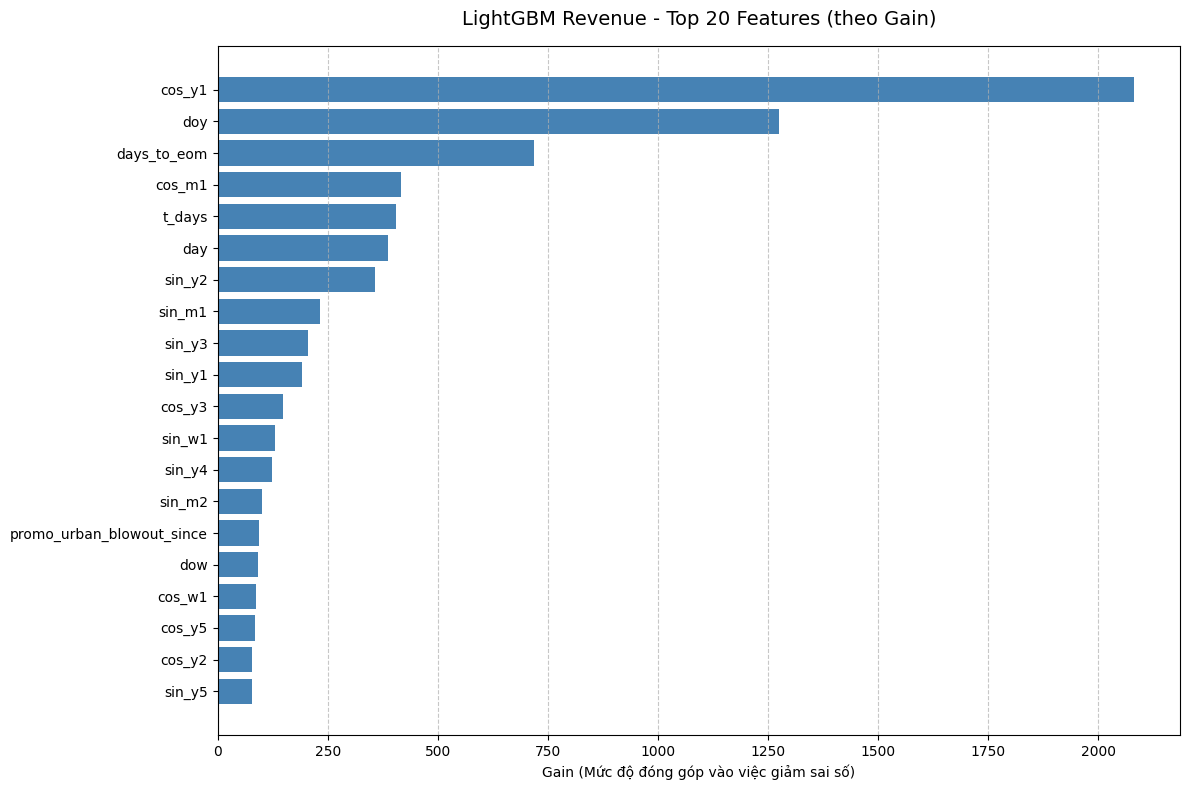

In [23]:
!pip install shap --quiet
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("="*50)
print(" 1. LIGHTGBM FEATURE IMPORTANCE (Base Revenue) ")
print("="*50)

# Lấy giá trị importance (mức độ đóng góp thông tin - gain) từ mô hình
importance_values = bf_rev.feature_importance(importance_type='gain')

# Ghép với danh sách tên cột (biến 'cols' đã được định nghĩa ở phần 4)
feature_imp = pd.DataFrame({'Feature': cols, 'Gain': importance_values})

# Sắp xếp và lấy Top 20 features quan trọng nhất
feature_imp = feature_imp.sort_values(by='Gain', ascending=True).tail(20)

# Vẽ biểu đồ ngang
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(feature_imp['Feature'], feature_imp['Gain'], color='steelblue')
ax.set_title("LightGBM Revenue - Top 20 Features (theo Gain)", fontsize=14, pad=15)
ax.set_xlabel("Gain (Mức độ đóng góp vào việc giảm sai số)")
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

 2. PROPHET COMPONENTS (Revenue) 


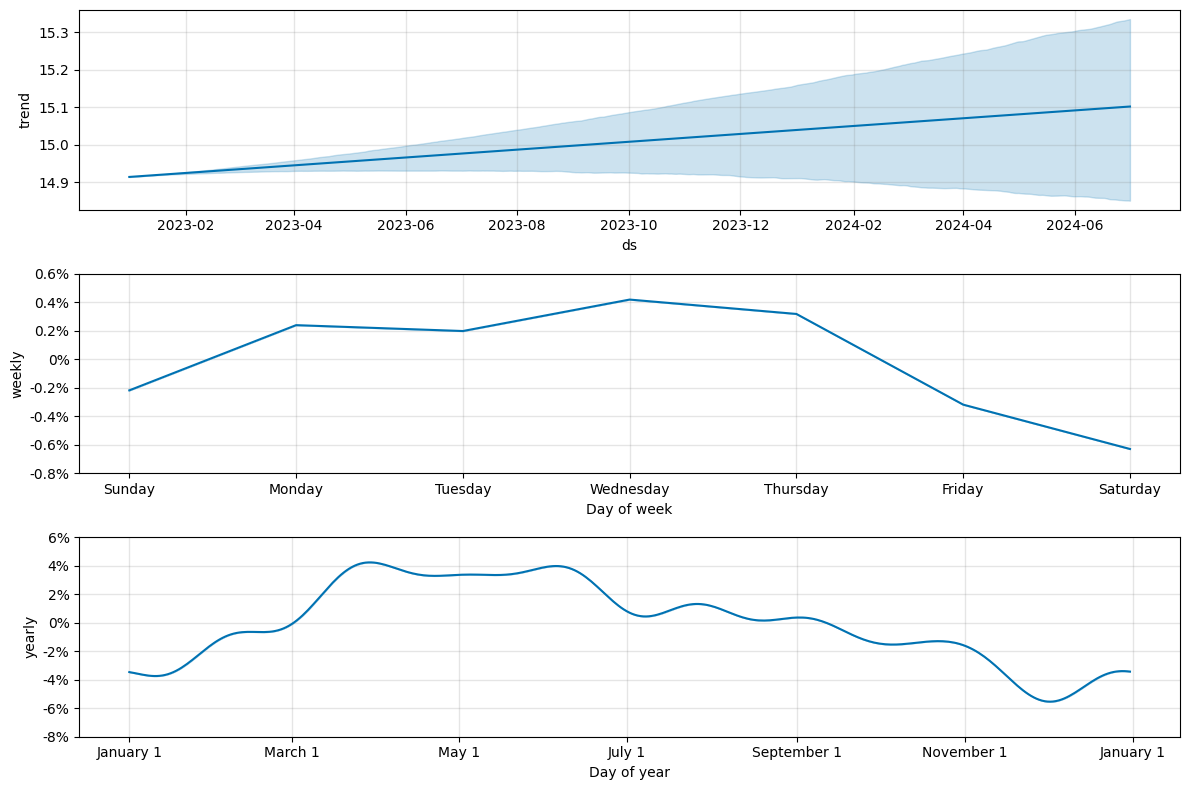

In [24]:
print("="*50)
print(" 2. PROPHET COMPONENTS (Revenue) ")
print("="*50)
# Sử dụng model Prophet mp_r và dataframe tập test (vdf) từ Phần 8
# Tạo forecast object để vẽ các thành phần (trend, seasonality, extra regressors)
forecast_r = mp_r.predict(vdf)
fig_prophet = mp_r.plot_components(forecast_r, figsize=(12, 8))
plt.show()

 3. SHAP VALUES (LightGBM Base Revenue) 


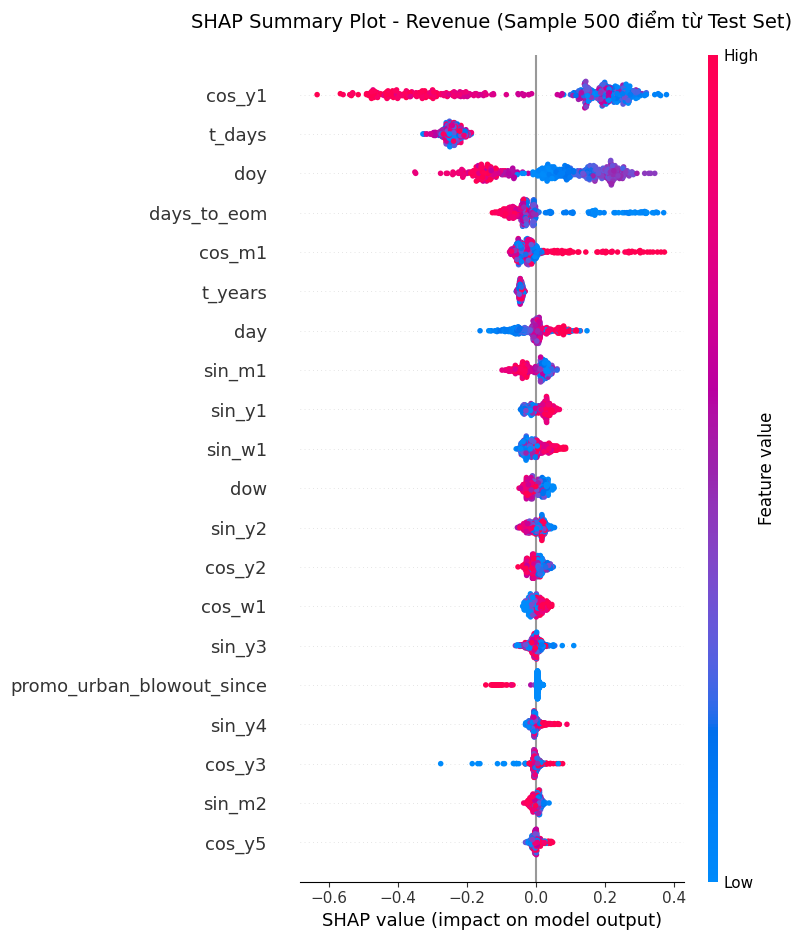

In [25]:
print("="*50)
print(" 3. SHAP VALUES (LightGBM Base Revenue) ")
print("="*50)
# Khởi tạo môi trường Javascript cho SHAP (nếu cần tương tác, ở đây dùng plot tĩnh)
shap.initjs()

# Tạo DataFrame cho X_te để SHAP có thể hiển thị tên cột
X_te_df = pd.DataFrame(X_te, columns=cols)

# Trích xuất một tập con ngẫu nhiên (vd: 500 dòng) từ tập test để tối ưu thời gian tính toán SHAP.
# Nếu tập test nhỏ, bạn có thể bỏ phần lấy sample và chạy trên toàn bộ X_te_df.
sample_size = min(500, X_te_df.shape[0])
X_te_sample = X_te_df.sample(n=sample_size, random_state=42)

# Khởi tạo TreeExplainer cho LightGBM
explainer = shap.TreeExplainer(bf_rev)
shap_values = explainer.shap_values(X_te_sample)

# Vẽ SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_te_sample, max_display=20, show=False)
plt.title(f"SHAP Summary Plot - Revenue (Sample {sample_size} điểm từ Test Set)", pad=20, fontsize=14)
plt.tight_layout()
plt.show()


 4. RIDGE REGRESSION COEFFICIENTS (Feature Importance) 


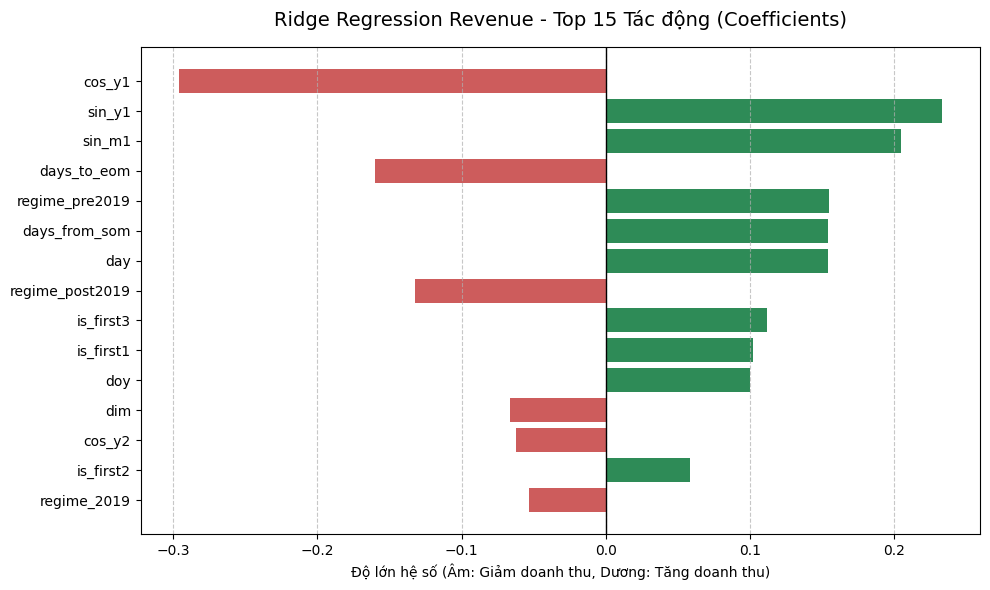

In [26]:
print("\n" + "="*50)
print(" 4. RIDGE REGRESSION COEFFICIENTS (Feature Importance) ")
print("="*50)

# ĐÃ SỬA LỖI: Trích xuất trực tiếp coef_ từ ridge_rev
coefficients = ridge_rev.coef_

# Tạo DataFrame
ridge_imp = pd.DataFrame({
    'Feature': cols,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients) # Lấy trị tuyệt đối để đo độ lớn tác động
})

# Sắp xếp lấy Top 15 features tác động mạnh nhất
ridge_imp = ridge_imp.sort_values(by='Abs_Coefficient', ascending=True).tail(15)

# Vẽ biểu đồ
fig, ax = plt.subplots(figsize=(10, 6))
# Phân màu: Xanh nếu hệ số dương (làm tăng doanh thu), Đỏ nếu hệ số âm (làm giảm doanh thu)
colors = ['seagreen' if c > 0 else 'indianred' for c in ridge_imp['Coefficient']]

ax.barh(ridge_imp['Feature'], ridge_imp['Coefficient'], color=colors)
ax.set_title("Ridge Regression Revenue - Top 15 Tác động (Coefficients)", fontsize=14, pad=15)
ax.set_xlabel("Độ lớn hệ số (Âm: Giảm doanh thu, Dương: Tăng doanh thu)")
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.show()